In [1]:
import datetime as dt
from src.preprocessing import preprocess_spy, preprocess_all_tickers, select_complete_tickers, count_tickers_with_expected_rows, plot_1min_intraday_midprices_and_returns

# Autorealod extension for Jupyter Notebooks
%load_ext autoreload
%autoreload 2

In [2]:
preprocess_spy()

2026-01-03 10:17:11,286 | INFO | SPY BBO already preprocessed, loading from parquet.


timestamp,mid_price_return
"datetime[μs, America/New_York]",f64
2015-01-02 09:32:00 EST,0.000194
2015-01-02 09:33:00 EST,0.001114
2015-01-02 09:34:00 EST,0.000339
2015-01-02 09:35:00 EST,-0.000629
2015-01-02 09:36:00 EST,0.000629
…,…
2017-04-12 15:56:00 EDT,0.000085
2017-04-12 15:57:00 EDT,0.0
2017-04-12 15:58:00 EDT,-0.000043


In [3]:
preprocess_all_tickers()

2026-01-03 10:17:11,380 | INFO | Starting preprocessing of all tickers...
2026-01-03 10:17:11,381 | INFO | Scanning RAW_FOLDER for tickers...
2026-01-03 10:17:11,529 | INFO | Found 103 tickers.
2026-01-03 10:17:11,530 | INFO | 9 tickers need preprocessing.


Preprocessing tickers:   0%|          | 0/9 [00:00<?, ?it/s]

2026-01-03 10:17:11,570 | INFO | === Preprocessing ticker WBA.N ===
2026-01-03 10:17:11,571 | INFO | [WBA.N] Extracting archives...
2026-01-03 10:17:11,597 | INFO | Loading parquet files in data/extracted/SP100/bbo/WBA.N...
2026-01-03 10:17:11,602 | INFO | Loaded 0 parquet files.
2026-01-03 10:17:11,602 | ERROR | No parquet files found for ticker WBA.N
2026-01-03 10:17:11,603 | ERROR | [WBA.N] Error during preprocessing: No parquet files found for ticker WBA.N
2026-01-03 10:17:11,604 | INFO | === Preprocessing ticker FB.N ===
2026-01-03 10:17:11,606 | INFO | [FB.N] Extracting archives...
2026-01-03 10:17:11,628 | INFO | Loading parquet files in data/extracted/SP100/bbo/FB.N...
2026-01-03 10:17:11,631 | INFO | Loaded 0 parquet files.
2026-01-03 10:17:11,631 | ERROR | No parquet files found for ticker FB.N
2026-01-03 10:17:11,633 | ERROR | [FB.N] Error during preprocessing: No parquet files found for ticker FB.N
2026-01-03 10:17:11,635 | INFO | === Preprocessing ticker KHC.N ===
2026-01-

In [4]:
select_complete_tickers(exception_dates=[dt.date(2015, 11, 27)], delete_exception_days=True)

2026-01-03 10:17:11,843 | INFO | Starting selection of complete tickers...
2026-01-03 10:17:14,283 | WARNING | [PYPL.OQ.parquet] Missing 136 trading days: [datetime.date(2015, 1, 2), datetime.date(2015, 1, 5), datetime.date(2015, 1, 6), datetime.date(2015, 1, 7), datetime.date(2015, 1, 8), datetime.date(2015, 1, 9), datetime.date(2015, 1, 12), datetime.date(2015, 1, 13), datetime.date(2015, 1, 14), datetime.date(2015, 1, 15), datetime.date(2015, 1, 16), datetime.date(2015, 1, 20), datetime.date(2015, 1, 21), datetime.date(2015, 1, 22), datetime.date(2015, 1, 23), datetime.date(2015, 1, 26), datetime.date(2015, 1, 27), datetime.date(2015, 1, 28), datetime.date(2015, 1, 29), datetime.date(2015, 1, 30), datetime.date(2015, 2, 2), datetime.date(2015, 2, 3), datetime.date(2015, 2, 4), datetime.date(2015, 2, 5), datetime.date(2015, 2, 6), datetime.date(2015, 2, 9), datetime.date(2015, 2, 10), datetime.date(2015, 2, 11), datetime.date(2015, 2, 12), datetime.date(2015, 2, 13), datetime.date(20

In [5]:
count_tickers_with_expected_rows()

2026-01-03 10:17:23,780 | INFO | Counting rows for each selected ticker...
2026-01-03 10:17:24,934 | INFO | Number of tickers with the expected number of rows: 91 out of 91


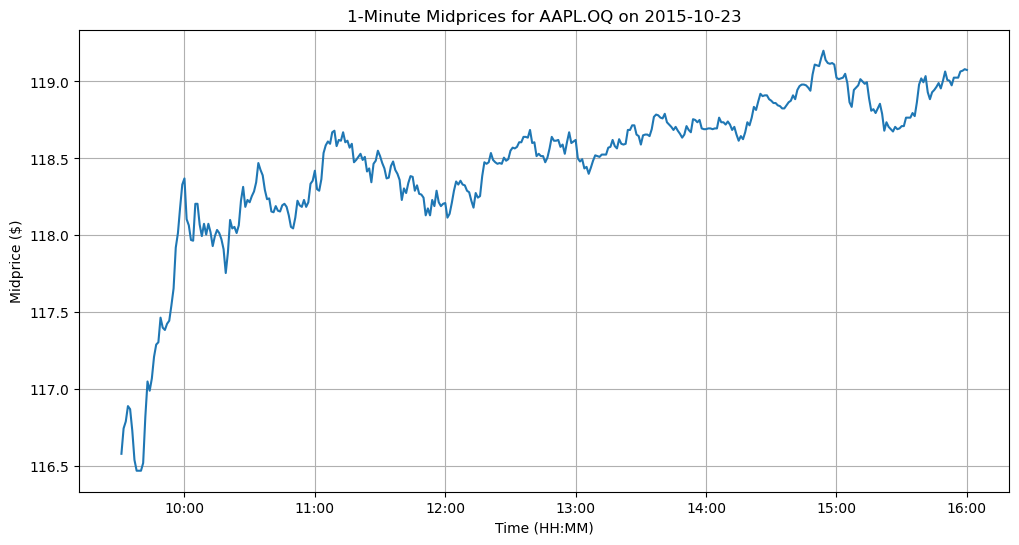

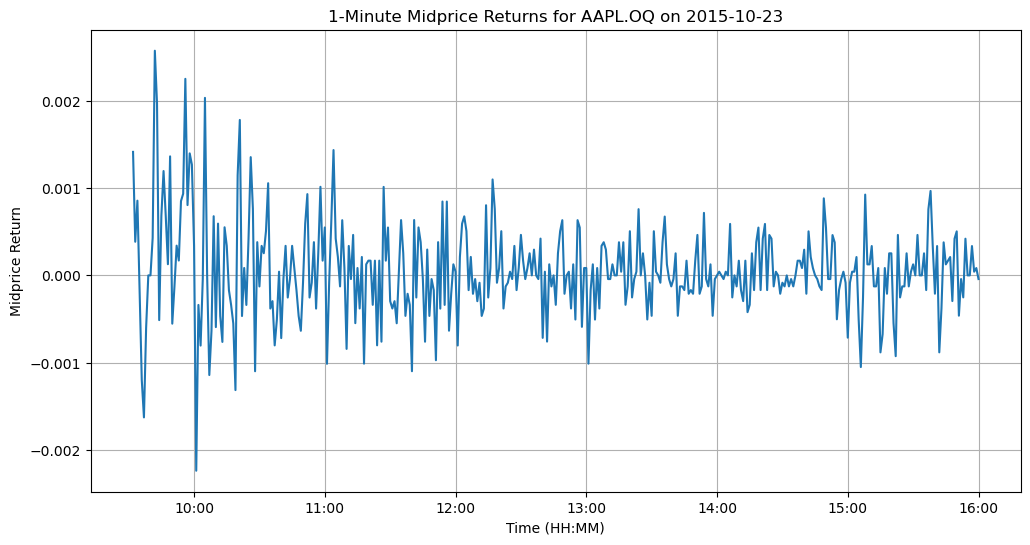

In [6]:
plot_1min_intraday_midprices_and_returns(ticker="AAPL.OQ", date=dt.date(2015, 10, 23))

In [5]:
from src.preprocessing import get_selected_tickers, load_selected_ticker_frames
from src.ocp import build_daily_return_matrices, build_daily_pairs, ocp_run_all_days_fast

from pathlib import Path

In [3]:
#1) Get selected tickers
tickers = get_selected_tickers()

# 2) Load per-ticker returns
frames = load_selected_ticker_frames()

2026-01-23 14:05:57,262 | INFO | Found 91 selected tickers.
2026-01-23 14:05:58,817 | INFO | Loaded 90 selected ticker frames into memory.


In [5]:
daily_matrices = build_daily_return_matrices(
    data_dir=Path("data/selected/SP100/bbo"),
    ticker_list=tickers,
    return_col="mid_price_return"
)

print(f"Built {len(daily_matrices)} daily return matrices.")

daily_pairs = build_daily_pairs(daily_matrices)

KeyboardInterrupt: 

In [ ]:
first_n_days = 573
daily_top = ocp_run_all_days_fast(
    daily_matrices=daily_matrices,
    daily_pairs=daily_pairs,
    top_k=10,
    keep_top_pairs=None,
    max_lag=50,       
    band=10,          
    first_n_days=first_n_days
)

daily_top.to_parquet(f"data/top_pairs/daily_top_pairs_{first_n_days}.parquet", index=False)

In [19]:
from src.trading import OCPTradeParams, run_backtest, show_final_strat_results, show_sensitivity_analysis

In [25]:
PAIRS_PATH = Path("data/top_pairs/daily_top_pairs_573_90.parquet")
RETURNS_DIR = Path("data/selected/SP100/bbo")
INDEX_TICKER = "SPY"

params = OCPTradeParams(tc_bps=0)

In [26]:
results = run_backtest(
    pairs_path=PAIRS_PATH,
    returns_dir=RETURNS_DIR,
    index_ticker=INDEX_TICKER,
    params=params,
)
results

trade_day,daily_pnl,pairs_used,entries,exits
date,f64,i64,i64,i64
2015-01-05,0.001986,5,20,20
2015-01-06,-0.005319,8,36,36
2015-01-07,-0.007188,4,14,14
2015-01-08,0.007352,5,26,26
2015-01-09,0.004583,2,8,8
…,…,…,…,…
2017-04-06,0.0,0,0,0
2017-04-07,0.0,0,0,0
2017-04-10,0.0,0,0,0



 FINAL STRATEGY RESULTS 
Total Return:      34.49%
Annualized Sharpe: 1.73
Max Drawdown:      -5.39%
Daily Win Rate:    46.85%
Total Trades:      9969



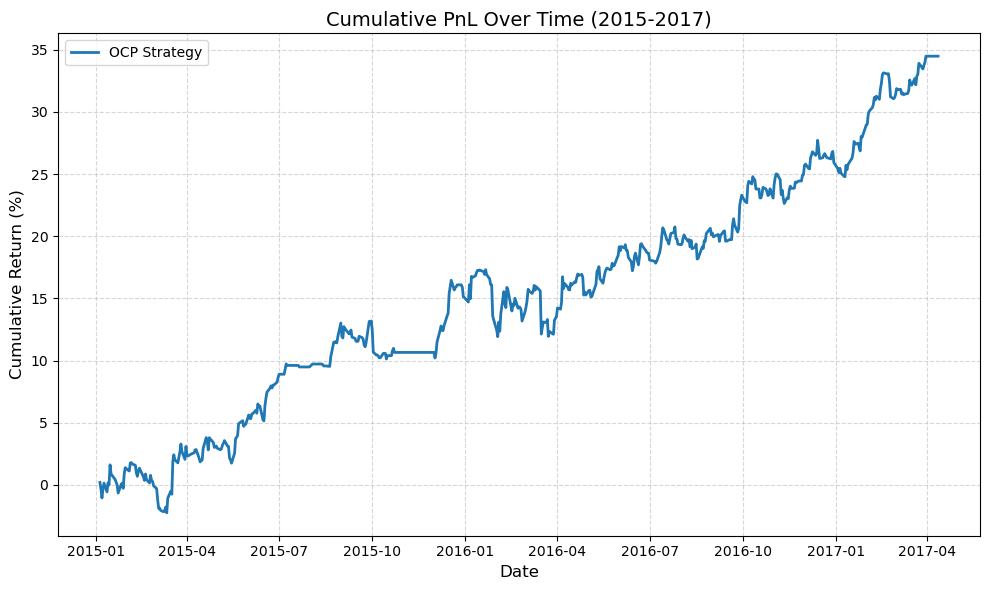

Saved: data/results_plots/cumulative_returns.png


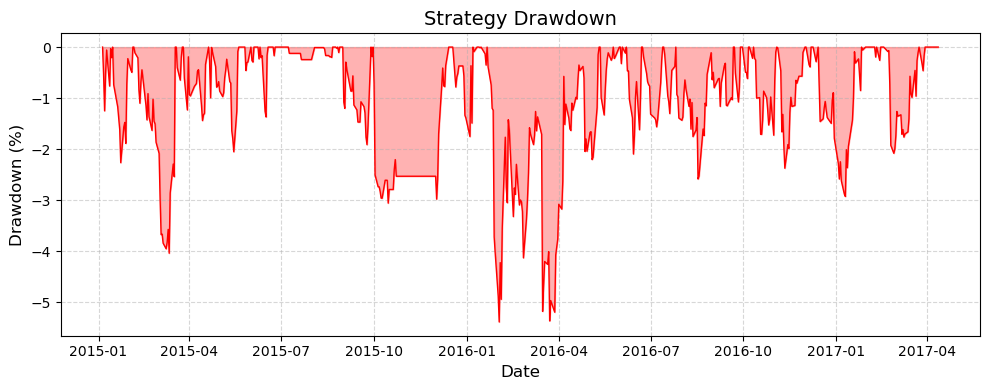

Saved: data/results_plots/drawdown.png


In [27]:
show_final_strat_results(results)

In [21]:
show_sensitivity_analysis()

Starting Sensitivity Analysis on 7 thresholds...
Testing r_bps = 4 ...


KeyboardInterrupt: 